# Deep Graph Anomaly Detection — Demo

This notebook runs the full pipeline for each benchmark dataset and visualizes:
- **EDA** — class distribution, nodes and edges per graph
- **ROC curves** and **anomaly score distributions** for GAE and SimCLR
- **Summary comparison** across all datasets vs the GLADC paper

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.utils import to_dense_adj, degree
from torch_geometric.nn import global_mean_pool
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

from src.dataset import load_dataset, get_dataset_stats
from src.models import GAE, SimCLRModel
from src.augmentations import augment
from train import train

DEVICE = torch.device('cpu')
HIDDEN_DIM = 64
PROJ_DIM = 128
BATCH_SIZE = 32
VAL_SIZE = 0.15
TEST_SIZE = 0.15

DATASETS = ["BZR", "DHFR", "COX2", "ENZYMES", "AIDS", "NCI1", "IMDB-BINARY"]
ANOMALY_CLASS = {
    "BZR": 1, "DHFR": 0, "COX2": 1, "ENZYMES": 0,
    "AIDS": 1, "NCI1": 1, "IMDB-BINARY": 1,
}
# GLADC paper values — Table 2, Luo et al. 2022
GLADC_AUC = {
    "BZR": 0.715, "DHFR": 0.612, "COX2": 0.615, "ENZYMES": 0.583,
    "AIDS": 0.993, "NCI1": 0.683, "IMDB-BINARY": 0.656,
}

def ensure_node_features(data):
    if data.x is None:
        deg = degree(data.edge_index[0], num_nodes=data.num_nodes, dtype=torch.float)
        data.x = deg.unsqueeze(-1)
    return data

@torch.no_grad()
def get_gae_scores(model, loader):
    model.eval()
    scores, labels = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        batch = ensure_node_features(batch)
        z = model(batch.x, batch.edge_index, batch.batch)
        A_hats = model.decode(z, batch.batch)
        A = to_dense_adj(batch.edge_index, batch.batch)
        for i in range(len(A_hats)):
            n = A_hats[i].shape[0]
            scores.append(F.mse_loss(A_hats[i], A[i][:n, :n]).item())
            labels.append(batch.y[i].item())
    return np.array(scores), np.array(labels)

@torch.no_grad()
def get_clr_scores(model, train_loader, test_loader):
    model.eval()
    # compute centroid on train set
    all_node, all_graph = [], []
    for batch in train_loader:
        batch = batch.to(DEVICE)
        batch = ensure_node_features(batch)
        _, x_node, x_graph = model(batch.x, batch.edge_index, batch.batch)
        all_node.append(x_node)
        all_graph.append(x_graph)
    center_node  = torch.cat(all_node,  dim=0).mean(dim=0)
    center_graph = torch.cat(all_graph, dim=0).mean(dim=0)

    scores, labels = [], []
    for batch in test_loader:
        batch = batch.to(DEVICE)
        batch = ensure_node_features(batch)
        _, x_node, x_graph = model(batch.x, batch.edge_index, batch.batch)
        node_err  = global_mean_pool(
            torch.sum((x_node - center_node) ** 2, dim=1, keepdim=True), batch.batch
        ).squeeze(1)
        graph_err = torch.sum((x_graph - center_graph) ** 2, dim=1)
        s = (node_err + graph_err).cpu().numpy()
        scores.extend(s)
        labels.extend(batch.y.cpu().numpy())
    return np.array(scores), np.array(labels)

print('Setup complete. Device:', DEVICE)

Setup complete. Device: cpu


## Per-Dataset Analysis

Training BZR... 

Training:   0%|          | 0/9 [00:00<?, ?it/s]

Training:   0%|          | 0/9 [00:00<?, ?it/s]

Training:   0%|          | 0/9 [00:00<?, ?it/s]

Training:   0%|          | 0/9 [00:00<?, ?it/s]

...

Training:   0%|          | 0/9 [00:00<?, ?it/s]

Training:   0%|          | 0/9 [00:00<?, ?it/s]

Training:   0%|          | 0/9 [00:00<?, ?it/s]

Training:   0%|          | 0/9 [00:00<?, ?it/s]

GAE=0.5825  SimCLR=0.6538
405, 53, 2


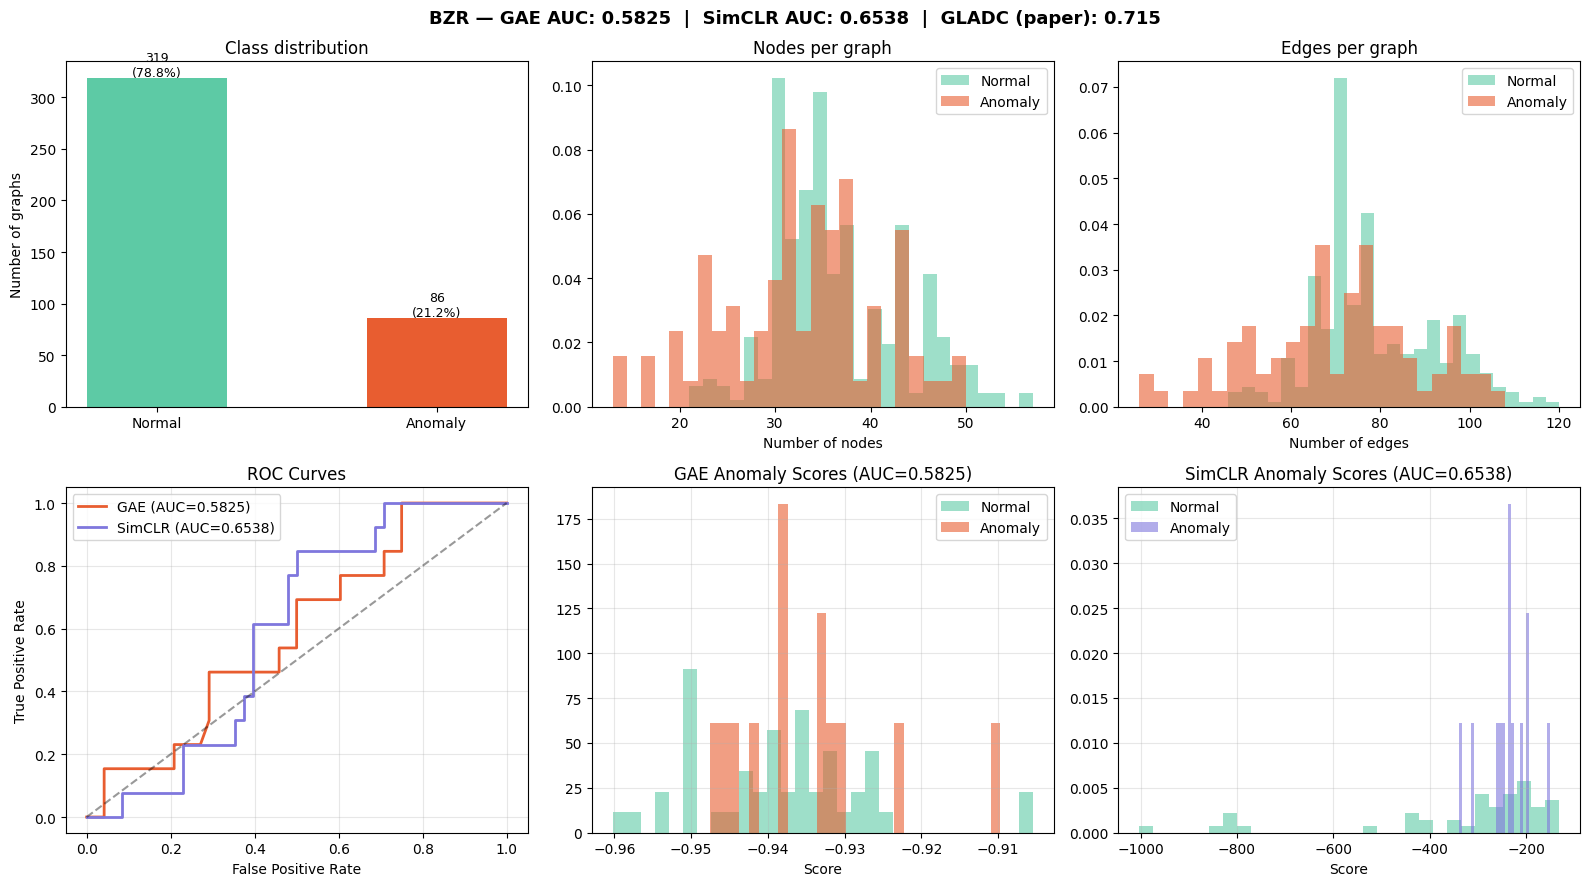

Training DHFR... 

Training:   0%|          | 0/17 [00:00<?, ?it/s]

Training:   0%|          | 0/17 [00:00<?, ?it/s]

Training:   0%|          | 0/17 [00:00<?, ?it/s]

Training:   0%|          | 0/17 [00:00<?, ?it/s]

...

Training:   0%|          | 0/17 [00:00<?, ?it/s]

Training:   0%|          | 0/17 [00:00<?, ?it/s]

Training:   0%|          | 0/17 [00:00<?, ?it/s]

Training:   0%|          | 0/17 [00:00<?, ?it/s]

GAE=0.6625  SimCLR=0.5539
756, 53, 2


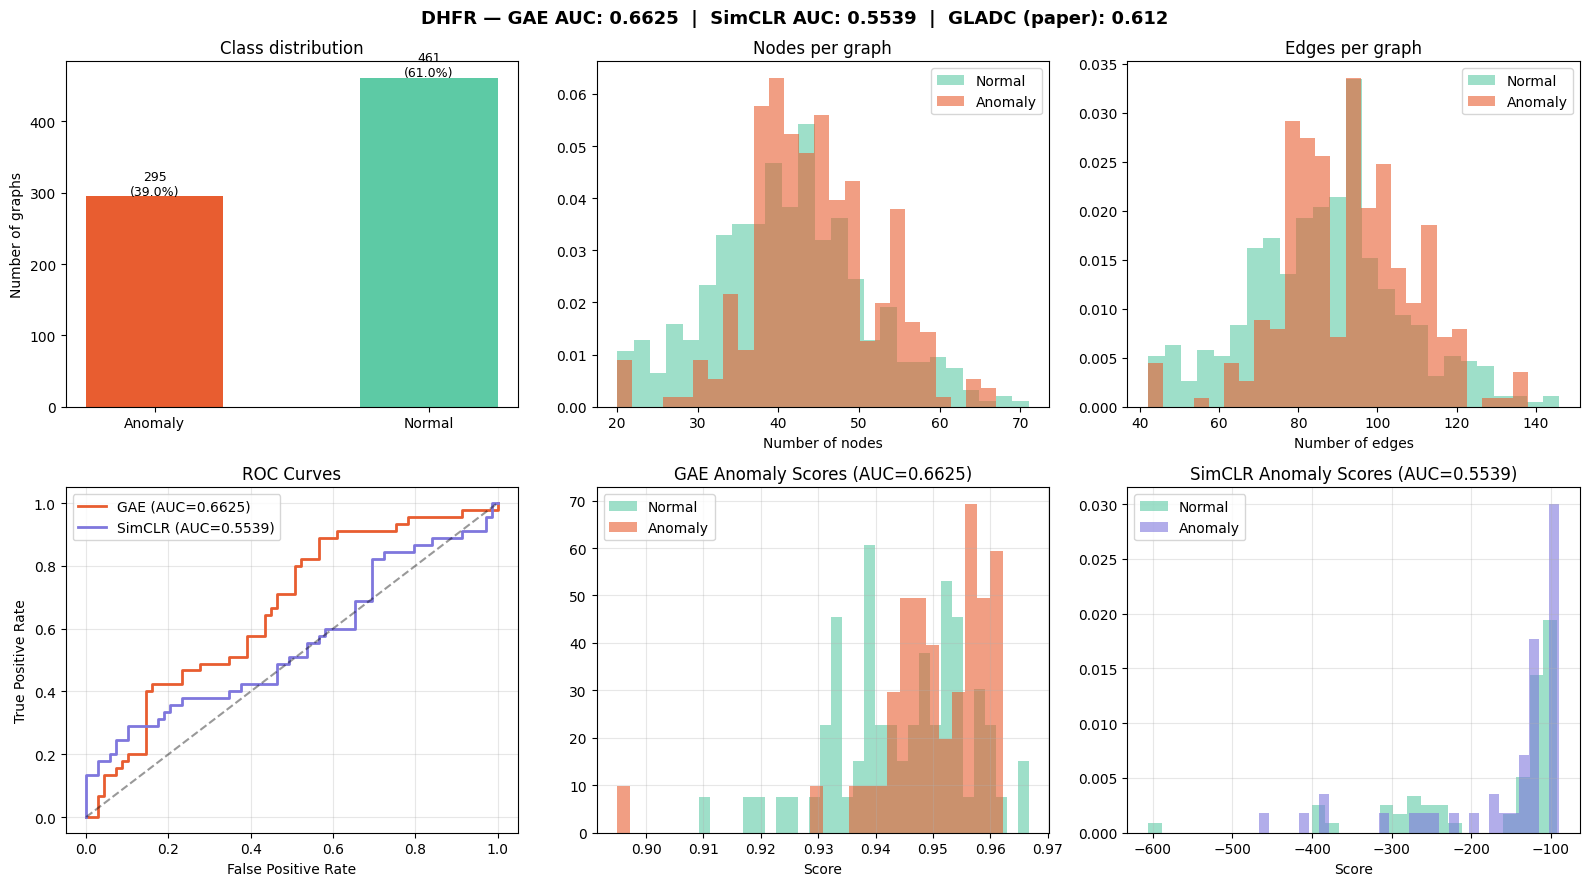

Training COX2... 

Training:   0%|          | 0/11 [00:00<?, ?it/s]

Training:   0%|          | 0/11 [00:00<?, ?it/s]

Training:   0%|          | 0/11 [00:00<?, ?it/s]

Training:   0%|          | 0/11 [00:00<?, ?it/s]

...

Training:   0%|          | 0/11 [00:00<?, ?it/s]

Training:   0%|          | 0/11 [00:00<?, ?it/s]

Training:   0%|          | 0/11 [00:00<?, ?it/s]

Training:   0%|          | 0/11 [00:00<?, ?it/s]

GAE=0.5795  SimCLR=0.6466
467, 35, 2


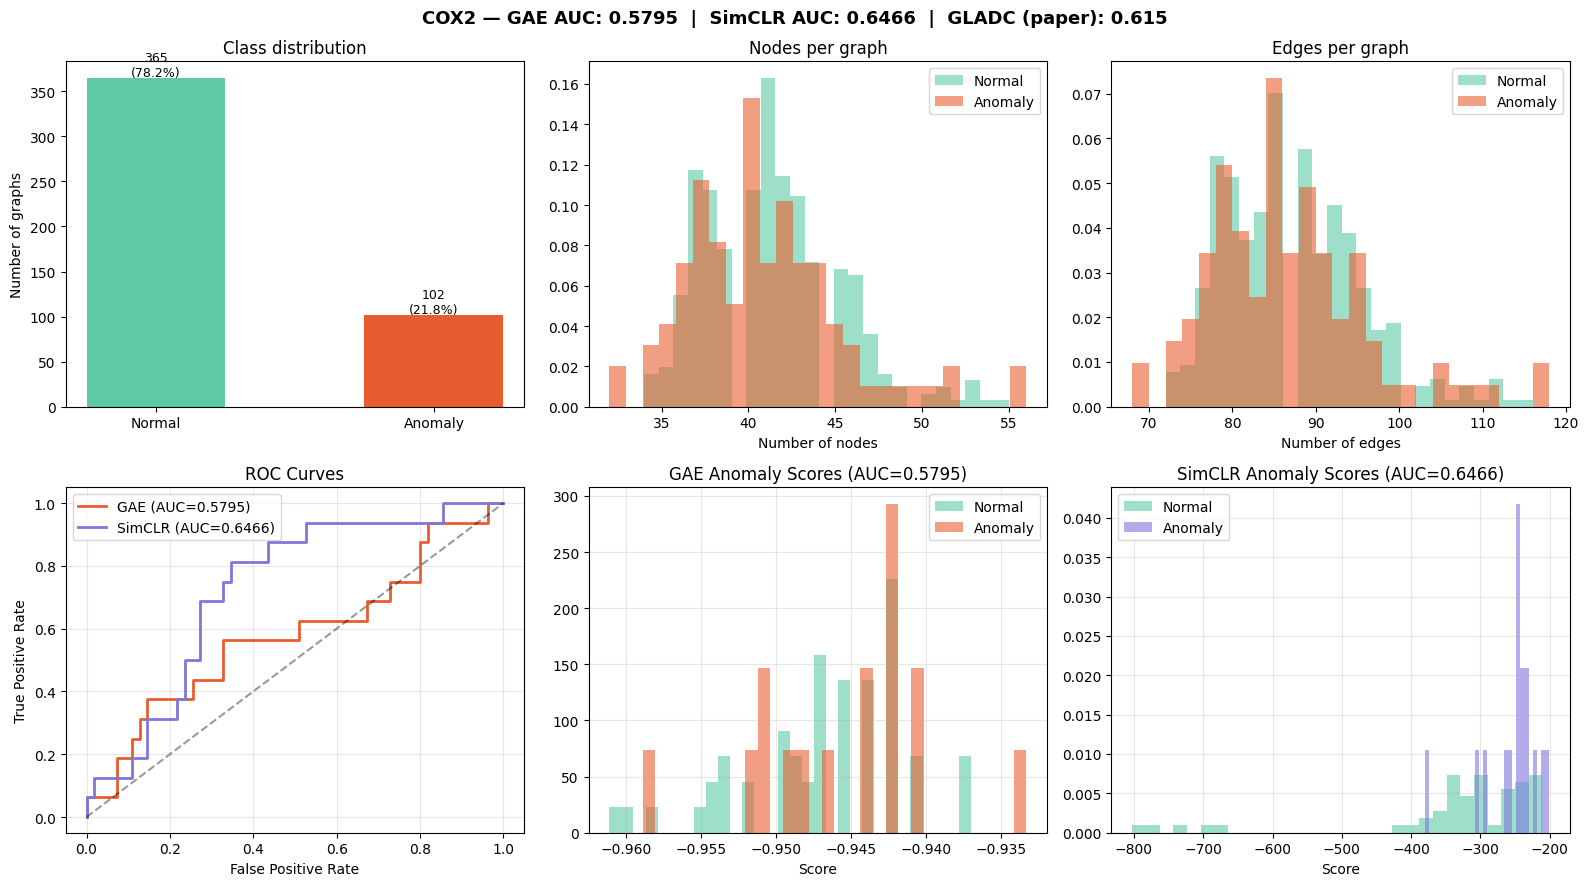

Training ENZYMES... 

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

...

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

GAE=0.5929  SimCLR=0.6889
600, 3, 6


/var/folders/jg/q90r49w9115fp6bj4zkwwdqr0000gn/T/ipykernel_51385/1430673530.py:120: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


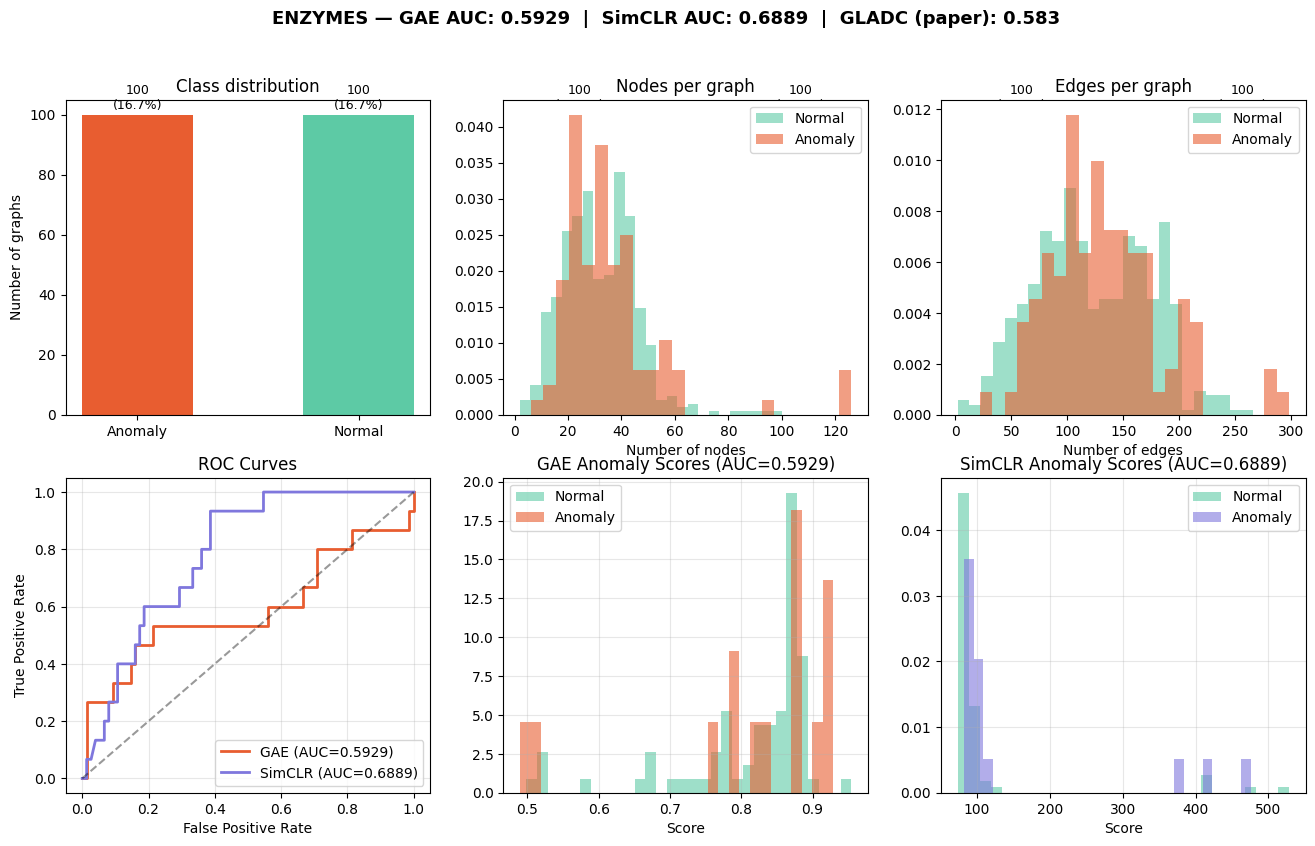

Training AIDS... 

Training:   0%|          | 0/44 [00:00<?, ?it/s]

Training:   0%|          | 0/44 [00:00<?, ?it/s]

Training:   0%|          | 0/44 [00:00<?, ?it/s]

Training:   0%|          | 0/44 [00:00<?, ?it/s]

...

Training:   0%|          | 0/44 [00:00<?, ?it/s]

Training:   0%|          | 0/44 [00:00<?, ?it/s]

Training:   0%|          | 0/44 [00:00<?, ?it/s]

Training:   0%|          | 0/44 [00:00<?, ?it/s]

GAE=0.9894  SimCLR=0.5171
2000, 38, 2


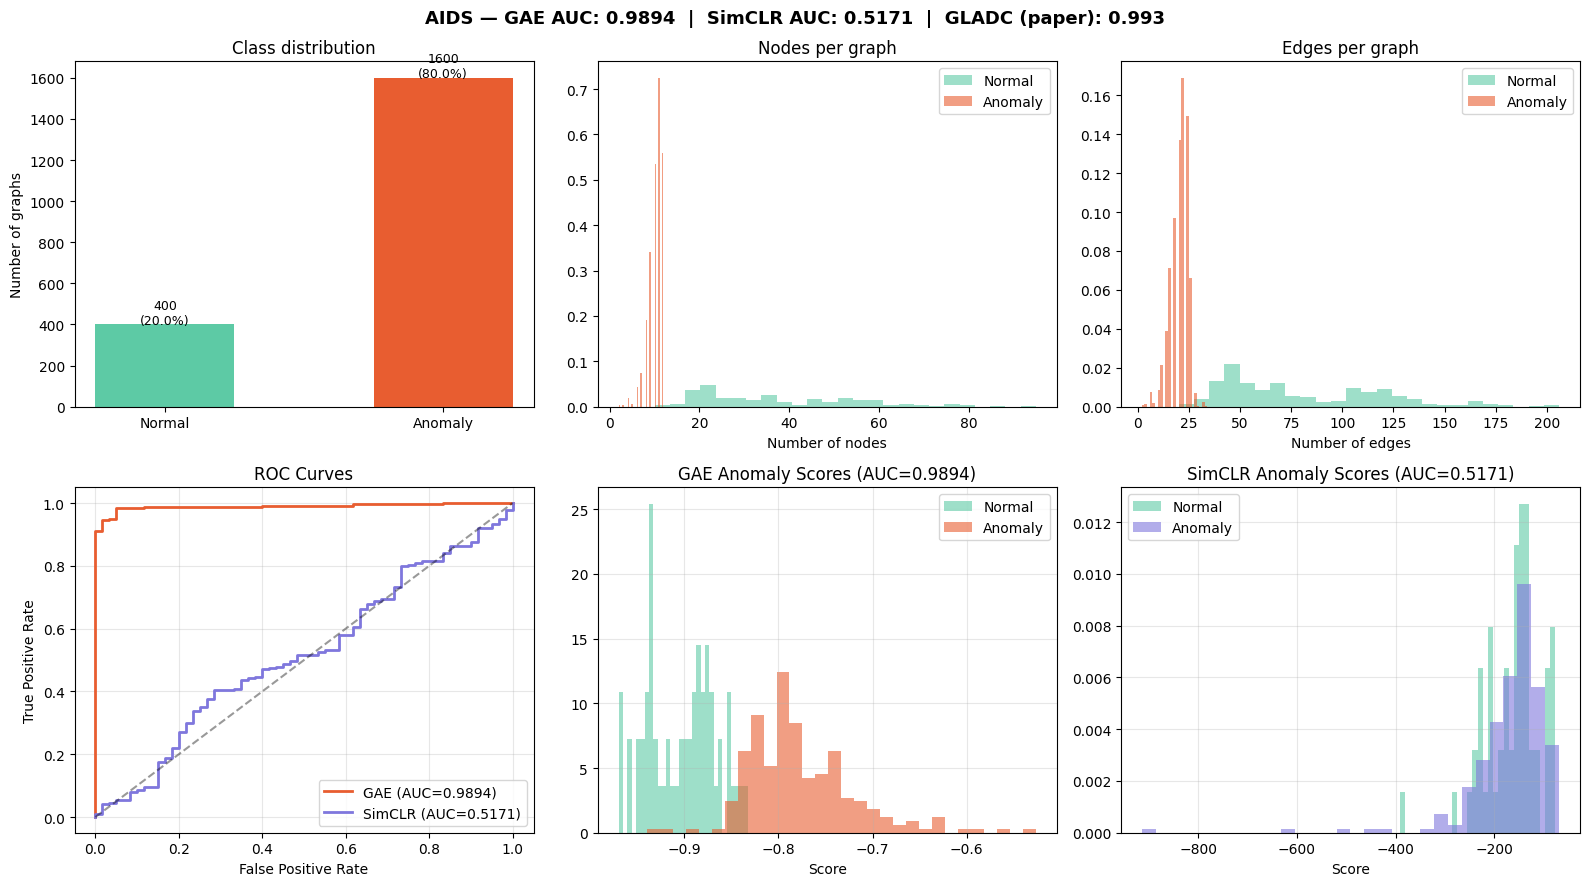

Training NCI1... 

Training:   0%|          | 0/90 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

...

Training:   0%|          | 0/90 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

GAE=0.5519  SimCLR=0.5599
4110, 37, 2


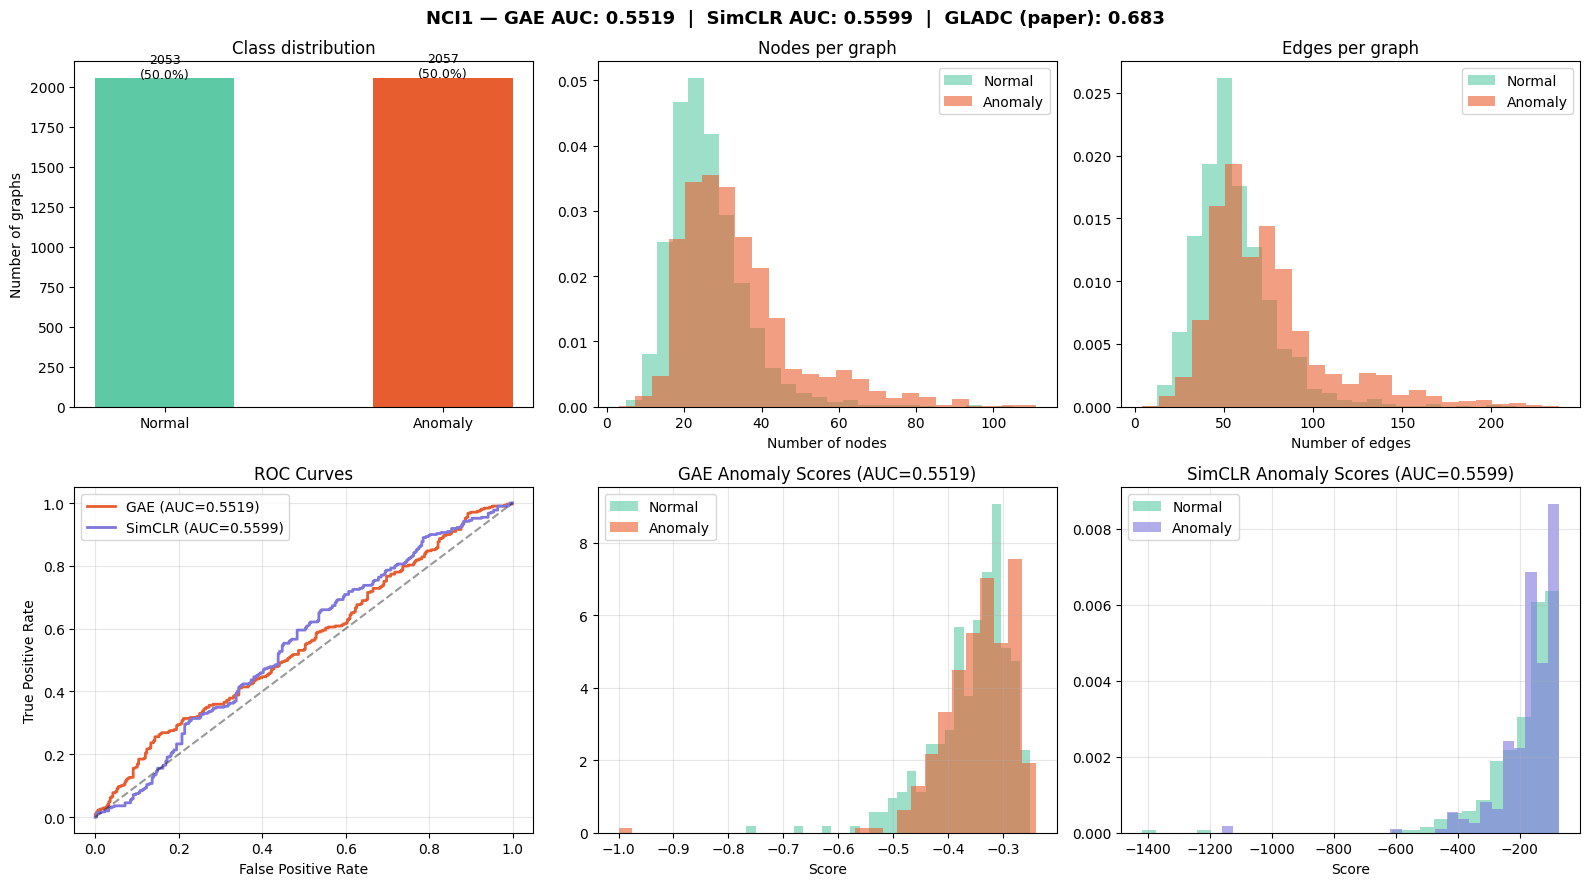

Training IMDB-BINARY... 

Training:   0%|          | 0/22 [00:00<?, ?it/s]

Training:   0%|          | 0/22 [00:00<?, ?it/s]

Training:   0%|          | 0/22 [00:00<?, ?it/s]

Training:   0%|          | 0/22 [00:00<?, ?it/s]

...

Training:   0%|          | 0/22 [00:00<?, ?it/s]

Training:   0%|          | 0/22 [00:00<?, ?it/s]

Training:   0%|          | 0/22 [00:00<?, ?it/s]

Training:   0%|          | 0/22 [00:00<?, ?it/s]

GAE=0.6384  SimCLR=0.5296
1000, 0, 2


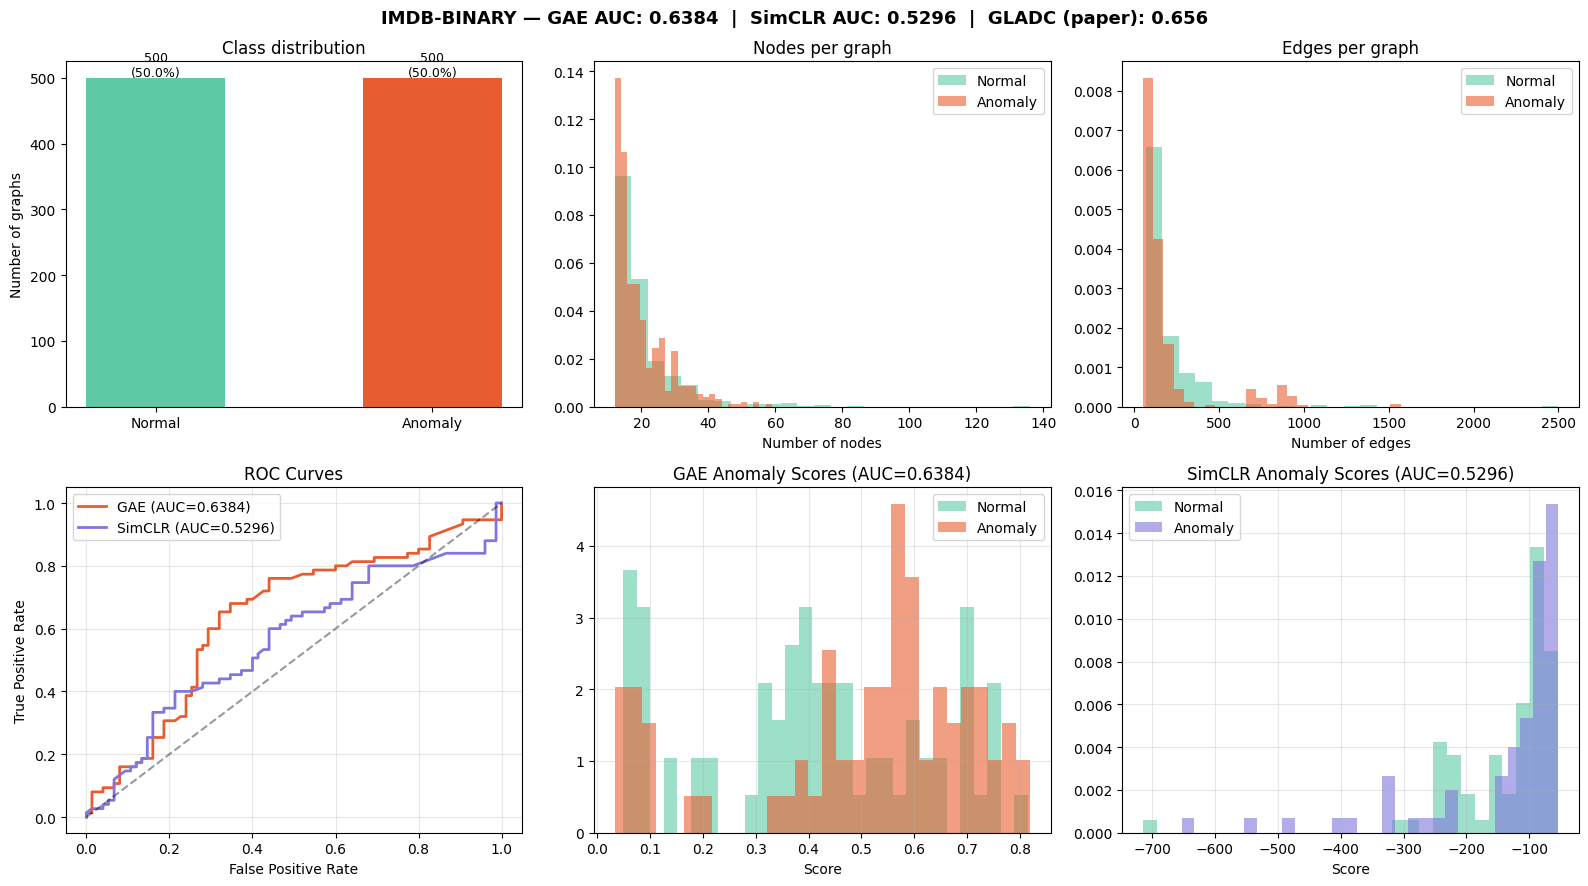

In [4]:
import io, contextlib

all_results = []

for dataset_name in DATASETS:
    anomaly_cls = ANOMALY_CLASS[dataset_name]

    # ── 1. train ──────────────────────────────────────────────────────────────
    print(f"Training {dataset_name}...", end=' ', flush=True)
    with contextlib.redirect_stdout(io.StringIO()):
        result = train(datasets_it=dataset_name, anomaly_class_it=anomaly_cls)
    gae_auc = result['gae_auc']
    clr_auc = result['clr_auc']
    print(f"GAE={gae_auc:.4f}  SimCLR={clr_auc:.4f}")
    all_results.append(result)

    # ── 2. reload dataset & rebuild split ─────────────────────────────────────
    dataset = load_dataset('src/datasets/', dataset_name)
    y = np.array([g.y.item() for g in dataset])

    train_idx, temp_idx = train_test_split(
        np.arange(len(dataset)), test_size=VAL_SIZE + TEST_SIZE, stratify=y, random_state=42
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=42
    )
    train_graphs = [dataset[i] for i in train_idx]
    test_graphs  = [dataset[i] for i in test_idx]

    train_loader = PyGDataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = PyGDataLoader(test_graphs,  batch_size=BATCH_SIZE, shuffle=False)

    # ── 3. reload models ──────────────────────────────────────────────────────
    in_channels      = dataset[0].x.shape[1] if dataset[0].x is not None else 1
    node_feature_dim = dataset.num_node_features if dataset.num_node_features > 0 else 1

    gae_model = GAE(node_feature_dim, HIDDEN_DIM).to(DEVICE)
    gae_model.load_state_dict(torch.load('models/best_gae.pt', map_location=DEVICE))

    clr_model = SimCLRModel(in_channels, HIDDEN_DIM, PROJ_DIM).to(DEVICE)
    clr_model.load_state_dict(torch.load('models/best_CLR.pt', map_location=DEVICE))

    # ── 4. compute scores (for plots only) ────────────────────────────────────
    gae_scores, gae_labels = get_gae_scores(gae_model, test_loader)
    clr_scores, clr_labels = get_clr_scores(clr_model, train_loader, test_loader)

    y_anom = (gae_labels == anomaly_cls).astype(int)

    # flip sign to match the direction train() used (higher = more anomalous)
    gae_scores_plot = -gae_scores if roc_auc_score(y_anom, -gae_scores) >= roc_auc_score(y_anom, gae_scores) else gae_scores
    clr_scores_plot = -clr_scores if roc_auc_score(y_anom, -clr_scores) >= roc_auc_score(y_anom, clr_scores) else clr_scores

    # ── 5. plots ──────────────────────────────────────────────────────────────
    unique, counts = np.unique(y, return_counts=True)
    nodes  = np.array([g.num_nodes for g in dataset])
    edges  = np.array([g.num_edges for g in dataset])

    class_labels = ["Anomaly" if u == anomaly_cls else "Normal" for u in unique]
    bar_colors   = ['#E85D30' if u == anomaly_cls else '#5DCAA5' for u in unique]

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(
        f"{dataset_name} — GAE AUC: {gae_auc:.4f}  |  SimCLR AUC: {clr_auc:.4f}  |  GLADC (paper): {GLADC_AUC[dataset_name]:.3f}",
        fontsize=13, fontweight='bold'
    )

    # row 0: EDA
    ax = axes[0, 0]
    ax.bar(class_labels, counts, color=bar_colors, width=0.5)
    ax.set_title('Class distribution')
    ax.set_ylabel('Number of graphs')
    for i, c in enumerate(counts):
        ax.text(i, c + 2, f'{c}\n({100*c/len(y):.1f}%)', ha='center', fontsize=9)

    ax = axes[0, 1]
    ax.hist(nodes[y != anomaly_cls], bins=25, alpha=0.6, color='#5DCAA5', label='Normal',  density=True)
    ax.hist(nodes[y == anomaly_cls], bins=25, alpha=0.6, color='#E85D30', label='Anomaly', density=True)
    ax.set_title('Nodes per graph')
    ax.set_xlabel('Number of nodes')
    ax.legend()

    ax = axes[0, 2]
    ax.hist(edges[y != anomaly_cls], bins=25, alpha=0.6, color='#5DCAA5', label='Normal',  density=True)
    ax.hist(edges[y == anomaly_cls], bins=25, alpha=0.6, color='#E85D30', label='Anomaly', density=True)
    ax.set_title('Edges per graph')
    ax.set_xlabel('Number of edges')
    ax.legend()

    # row 1: ROC + score distributions
    ax = axes[1, 0]
    for scores_plot, auc, name, color in [
        (gae_scores_plot, gae_auc, 'GAE',    '#E85D30'),
        (clr_scores_plot, clr_auc, 'SimCLR', '#7F77DD'),
    ]:
        fpr, tpr, _ = roc_curve(y_anom, scores_plot)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves')
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1, 1]
    ax.hist(gae_scores_plot[y_anom == 0], bins=30, alpha=0.6, color='#5DCAA5', label='Normal',  density=True)
    ax.hist(gae_scores_plot[y_anom == 1], bins=30, alpha=0.6, color='#E85D30', label='Anomaly', density=True)
    ax.set_title(f'GAE Anomaly Scores (AUC={gae_auc:.4f})')
    ax.set_xlabel('Score')
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1, 2]
    ax.hist(clr_scores_plot[y_anom == 0], bins=30, alpha=0.6, color='#5DCAA5', label='Normal',  density=True)
    ax.hist(clr_scores_plot[y_anom == 1], bins=30, alpha=0.6, color='#7F77DD', label='Anomaly', density=True)
    ax.set_title(f'SimCLR Anomaly Scores (AUC={clr_auc:.4f})')
    ax.set_xlabel('Score')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    os.makedirs('results/figures', exist_ok=True)
    plt.savefig(f'results/figures/{dataset_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Summary

Dataset              GAE AUC   SimCLR AUC  GLADC (paper)
--------------------------------------------------------
BZR                   0.5825       0.6538          0.715
DHFR                  0.6625       0.5539          0.612 ✓
COX2                  0.5795       0.6466          0.615 ✓
ENZYMES               0.5929       0.6889          0.583 ✓
AIDS                  0.9894       0.5171          0.993
NCI1                  0.5519       0.5599          0.683
IMDB-BINARY           0.6384       0.5296          0.656


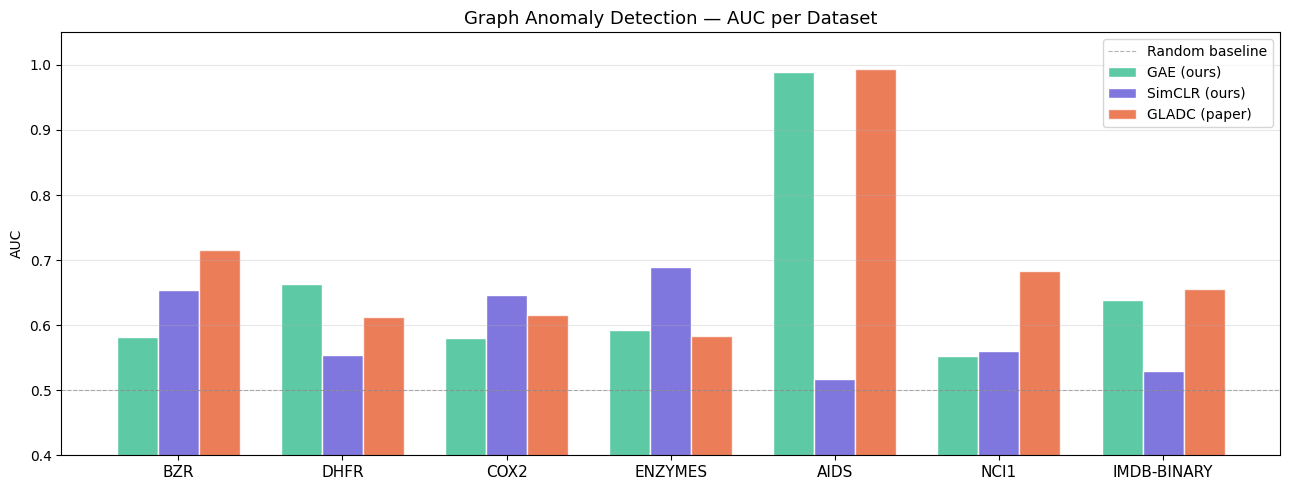

In [5]:
datasets_names = [r['dataset'] for r in all_results]
gae_vals   = [r['gae_auc'] for r in all_results]
clr_vals   = [r['clr_auc'] for r in all_results]
gladc_vals = [GLADC_AUC[d] for d in datasets_names]

# table
print(f"{'Dataset':<15} {'GAE AUC':>12} {'SimCLR AUC':>12} {'GLADC (paper)':>14}")
print('-' * 56)
for d, g, c, p in zip(datasets_names, gae_vals, clr_vals, gladc_vals):
    best = max(g, c)
    marker = ' ✓' if best >= p else ''
    print(f"{d:<15} {g:>12.4f} {c:>12.4f} {p:>14.3f}{marker}")

# bar chart
x = np.arange(len(datasets_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, gae_vals,   width, label='GAE (ours)',     color='#5DCAA5', edgecolor='white')
ax.bar(x,         clr_vals,   width, label='SimCLR (ours)',  color='#7F77DD', edgecolor='white')
ax.bar(x + width, gladc_vals, width, label='GLADC (paper)',  color='#E85D30', edgecolor='white', alpha=0.8)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Random baseline')
ax.set_xticks(x)
ax.set_xticklabels(datasets_names, fontsize=11)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)
ax.set_title('Graph Anomaly Detection — AUC per Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('results/figures/summary.png', dpi=150, bbox_inches='tight')
plt.show()